In [23]:
import sys
sys.path.append('../')

In [24]:
import torch
import gpr_grad
from gpr_grad import RDFKernelFunction, GradientGP, CUR_deterministic

In [25]:
""" Run partial-gradient test """

torch.set_default_dtype(torch.float64)

def f_true(X):
    x = X[:, 0]
    y = X[:, 1]
    return torch.sin(2.0 * x) + 0.5 * torch.cos(3.0 * y)

def grad_true(X):
    x = X[:, 0]
    y = X[:, 1]

    gx = 2.0 * torch.cos(2.0 * x)
    gy = -1.5 * torch.sin(3.0 * y)

    return torch.stack([gx, gy], dim=1)


# -----------------------------
# training data
# -----------------------------
X_f = torch.tensor([
    [-1.0, -1.0],
    [ 0.0,  0.0],
])

Y_f = f_true(X_f)

X_g = torch.tensor([
    [-0.8,  0.5],
    [-0.5,  0.2],
    [ 0.3, -0.4],
    [ 0.9,  0.7],
    [ 0.6, -0.6],
])

G_full = grad_true(X_g)

# Only use selected gradient components:
#
# [point index, gradient dimension]
#
# dim 0 = df/dx
# dim 1 = df/dy
grad_indices = torch.tensor([
    [0, 0],   # df/dx at X_g[0]
    [1, 1],   # df/dy at X_g[1]
    [2, 0],   # df/dx at X_g[2]
    [3, 1],   # df/dy at X_g[3]
    [4, 0],   # df/dx at X_g[4]
    [4, 1],   # df/dy at X_g[4]
], dtype=torch.long)

G_g = torch.stack([
    G_full[point_id, dim_id]
    for point_id, dim_id in grad_indices
])


# -----------------------------
# fit GP
# -----------------------------
kernel = RDFKernelFunction(theta=torch.tensor([0.8, 0.8]))

gp = GradientGP(
    kernel=kernel,
    sigma_f=1e-8,
    sigma_g=1e-8,
    jitter=1e-10,
)

gp.fit(
    X_f=X_f,
    Y_f=Y_f,
    X_g=X_g,
    G_g=G_g,  # or use G_full here for all gradients
    grad_indices=grad_indices,
)


# -----------------------------
# prediction grid
# -----------------------------
xs = torch.linspace(-1.0, 1.0, 20)
ys = torch.linspace(-1.0, 1.0, 20)
xx, yy = torch.meshgrid(xs, ys, indexing="ij")
X_star = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

mean, cov = gp.predict(X_star)

Y_star = f_true(X_star)

rmse = torch.sqrt(torch.mean((mean - Y_star) ** 2))
mae = torch.mean(torch.abs(mean - Y_star))

print("RMSE:", rmse.item())
print("MAE: ", mae.item())
print("Cov min eig:", torch.linalg.eigvalsh(cov).min().item())


# -----------------------------
# interpolation sanity check at function points
# -----------------------------
mean_f, _ = gp.predict(X_f)

print("\nFunction interpolation")
print("true Y_f:", Y_f)
print("pred Y_f:", mean_f)
print("max abs error at X_f:", torch.max(torch.abs(mean_f - Y_f)).item())


# -----------------------------
# finite-difference sanity check
# only for OBSERVED gradient components
# -----------------------------
eps = 1e-5

print("\nObserved partial-gradient interpolation")

for m in range(grad_indices.shape[0]):
    point_id = grad_indices[m, 0].item()
    dim_id = grad_indices[m, 1].item()

    x0 = X_g[point_id].clone()

    xp = x0.clone()
    xm = x0.clone()
    xp[dim_id] += eps
    xm[dim_id] -= eps

    fp = gp.predict(xp[None, :], return_cov=False)[0]
    fm = gp.predict(xm[None, :], return_cov=False)[0]

    pred_grad = (fp - fm) / (2 * eps)
    true_grad = G_full[point_id, dim_id]

    print(f"\nX_g[{point_id}], dim {dim_id}")
    print("x0:", x0)
    print("true observed grad:", true_grad.item())
    print("pred observed grad:", pred_grad.item())
    print("abs error:", torch.abs(pred_grad - true_grad).item())


# -----------------------------
# optional: compare full predicted gradients,
# including unobserved components
# -----------------------------
print("\nFull gradient prediction at X_g")

for i in range(X_g.shape[0]):
    x0 = X_g[i].clone()

    pred_grad = []
    for d in range(X_g.shape[1]):
        xp = x0.clone()
        xm = x0.clone()
        xp[d] += eps
        xm[d] -= eps

        fp = gp.predict(xp[None, :], return_cov=False)[0]
        fm = gp.predict(xm[None, :], return_cov=False)[0]

        pred_grad.append((fp - fm) / (2 * eps))

    pred_grad = torch.stack(pred_grad)

    print(f"\nX_g[{i}] =", x0)
    print("true grad:", G_full[i])
    print("pred grad:", pred_grad)
    print("abs error:", torch.abs(pred_grad - G_full[i]))

RMSE: 0.2109771965716921
MAE:  0.17441857257015012
Cov min eig: -2.8872305990134865e-15

Function interpolation
true Y_f: tensor([-1.4043,  0.5000])
pred Y_f: tensor([-1.4043,  0.5000])
max abs error at X_f: 1.6994849971752046e-10

Observed partial-gradient interpolation

X_g[0], dim 0
x0: tensor([-0.8000,  0.5000])
true observed grad: -0.05839904460257763
pred observed grad: -0.058399044539081395
abs error: 6.349623604684496e-11

X_g[1], dim 1
x0: tensor([-0.5000,  0.2000])
true observed grad: -0.8469637100925532
pred observed grad: -0.8469637098440507
abs error: 2.4850255186947834e-10

X_g[2], dim 0
x0: tensor([ 0.3000, -0.4000])
true observed grad: 1.6506712298193567
pred observed grad: 1.6506712295694113
abs error: 2.499453977122812e-10

X_g[3], dim 1
x0: tensor([0.9000, 0.7000])
true observed grad: -1.294814049973311
pred observed grad: -1.294814049912496
abs error: 6.081490866449712e-11

X_g[4], dim 0
x0: tensor([ 0.6000, -0.6000])
true observed grad: 0.7247155089533472
pred obse

In [26]:
K_point = gp.predict_grad_cov_by_points(X_star)

idx_select, err = CUR_deterministic(
    K_point.detach(),
    n_col=7,
    error_estimate=True,
)

X_selected = X_star[idx_select]

In [27]:
X_selected

tensor([[-1.0000, -1.0000],
        [ 0.6842,  1.0000],
        [ 0.0526, -1.0000],
        [-0.7895,  1.0000],
        [-0.3684, -0.3684],
        [ 0.8947,  0.1579],
        [-0.0526,  0.6842]])

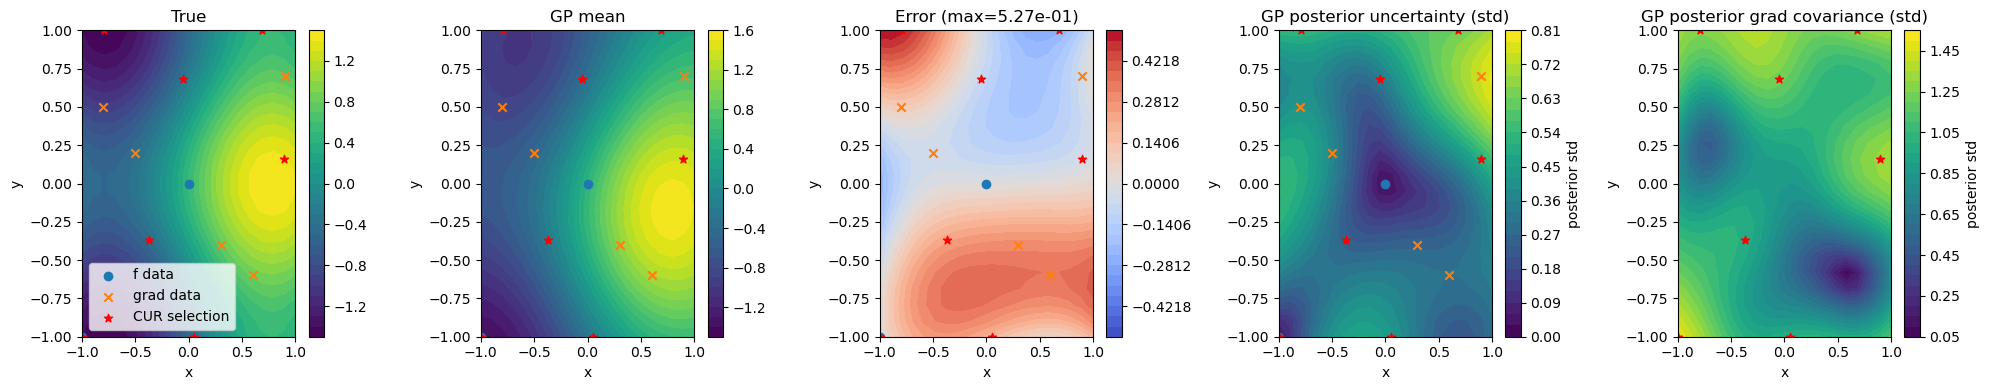

In [28]:
import matplotlib.pyplot as plt

Z_true = Y_star.reshape(20, 20)
Z_pred = mean.reshape(20, 20).detach()
Z_err  = (mean - Y_star).reshape(20, 20).detach()

err_max = torch.max(torch.abs(Z_err)).item()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# --- True ---
cf0 = axes[0].contourf(xx, yy, Z_true, levels=30)
axes[0].scatter(X_f[:, 0], X_f[:, 1], marker="o", label="f data")
axes[0].scatter(X_g[:, 0], X_g[:, 1], marker="x", label="grad data")

axes[0].scatter(X_selected[:, 0], X_selected[:, 1], c='r', marker="*", label="CUR selection")


fig.colorbar(cf0, ax=axes[0])
axes[0].set_title("True")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# --- Prediction ---
cf1 = axes[1].contourf(xx, yy, Z_pred, levels=30)
axes[1].scatter(X_f[:, 0], X_f[:, 1], marker="o")
axes[1].scatter(X_g[:, 0], X_g[:, 1], marker="x")

axes[1].scatter(X_selected[:, 0], X_selected[:, 1], c='r', marker="*", label="CUR selection")

fig.colorbar(cf1, ax=axes[1])
axes[1].set_title("GP mean")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

# --- Error ---
cf2 = axes[2].contourf(
    xx, yy, Z_err,
    levels=torch.linspace(-err_max, err_max, 31),
    cmap="coolwarm",
    vmin=-err_max,
    vmax=err_max,
)
axes[2].scatter(X_f[:, 0], X_f[:, 1], marker="o")
axes[2].scatter(X_g[:, 0], X_g[:, 1], marker="x")

axes[2].scatter(X_selected[:, 0], X_selected[:, 1], c='r', marker="*", label="CUR selection")


fig.colorbar(cf2, ax=axes[2])
axes[2].set_title(f"Error (max={err_max:.2e})")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

# --- Uncertainty from covariance ---
# cov is (Ns, Ns)
std = torch.sqrt(torch.clamp(torch.diag(cov), min=0.0))
Z_std = std.reshape(20, 20).detach()

cf = axes[3].contourf(xx, yy, Z_std, levels=30)
axes[3].scatter(X_f[:, 0], X_f[:, 1], marker="o", label="f data")
axes[3].scatter(X_g[:, 0], X_g[:, 1], marker="x", label="grad data")

axes[3].scatter(X_selected[:, 0], X_selected[:, 1], c='r', marker="*", label="CUR selection")

fig.colorbar(cf, ax=axes[3], label="posterior std")

axes[3].set_title("GP posterior uncertainty (std)")
axes[3].set_xlabel("x")
axes[3].set_ylabel("y")


# --- Grad covariance ---
# cov is (Ns, Ns)
std = torch.sqrt(torch.clamp(torch.diag(K_point), min=0.0))
Z_std = std.reshape(20, 20).detach()
cf = axes[4].contourf(xx, yy, Z_std, levels=30)

axes[4].scatter(X_selected[:, 0], X_selected[:, 1], c='r', marker="*", label="CUR selection")

fig.colorbar(cf, ax=axes[4], label="posterior std")

axes[4].set_title("GP posterior grad covariance (std)")
axes[4].set_xlabel("x")
axes[4].set_ylabel("y")



axes[0].legend()

plt.tight_layout()
plt.show()